<a href="https://colab.research.google.com/github/dudinha-web/fundamentos-de-ia/blob/main/Aula_10_Lab_titanic_kaggle.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Titanic Survival Prediction

---

## 1. Introdução
O naufrágio do Titanic (1912) é um dos eventos mais estudados em ciência de dados. Este notebook foi estruturado como **aula introdutória**, explicando **cada coluna**, **cada gráfico** e **cada etapa** do processo de Machine Learning.

---

## Objetivo
Prever a variável **Survived**:
- 0 → Não sobreviveu
- 1 → Sobreviveu

---

## 2. Dicionário de Dados (Explicação de TODAS as Colunas)

| Coluna | Descrição |
|------|----------|
| PassengerId | Identificador único do passageiro |
| Survived | Variável alvo (0 = morreu, 1 = sobreviveu) |
| Pclass | Classe do ticket (1 = alta, 2 = média, 3 = baixa) |
| Name | Nome do passageiro |
| Sex | Sexo |
| Age | Idade |
| SibSp | Nº de irmãos/cônjuges a bordo |
| Parch | Nº de pais/filhos a bordo |
| Ticket | Número do ticket |
| Fare | Valor pago pela passagem |
| Cabin | Cabine |
| Embarked | Porto de embarque (C, Q, S) |


Link KAGGLE - https://www.kaggle.com/competitions/titanic/overview

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Carregamento dos dados

In [9]:
df = pd.read_csv('/content/Titanic-Dataset.csv')
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [12]:
df.info()
df.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,0
PassengerId,int64
Survived,int64
Pclass,int64
Name,object
Sex,object
Age,float64
SibSp,int64
Parch,int64
Ticket,object
Fare,float64


In [13]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


# Análise Exploratória

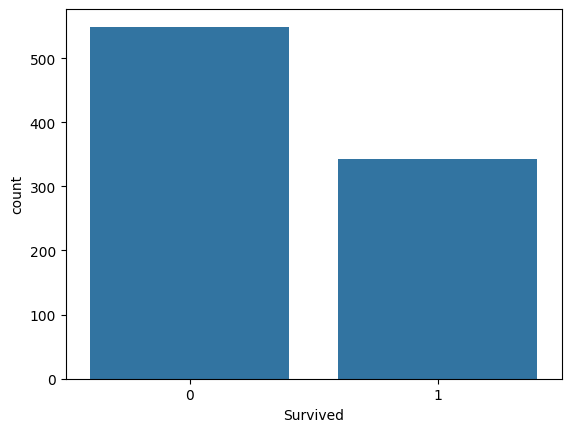

In [4]:
sns.countplot(x='Survived', data=df)
plt.show() #Biblioteca seablock

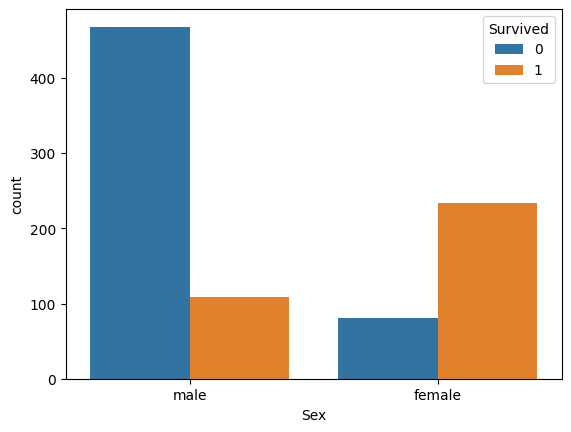

In [5]:
sns.countplot(x='Sex', hue='Survived', data=df)
plt.show()

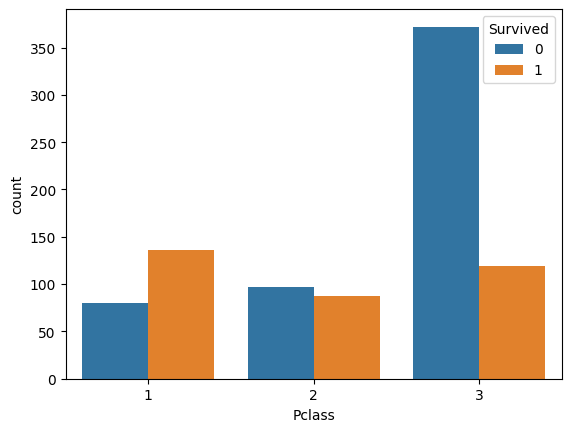

In [14]:
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.show()

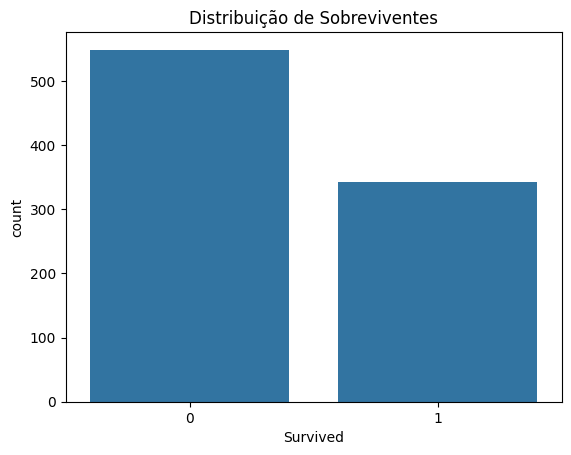

In [15]:
# Distribuição da variável alvo
sns.countplot(x='Survived', data=df)
plt.title('Distribuição de Sobreviventes')
plt.show()

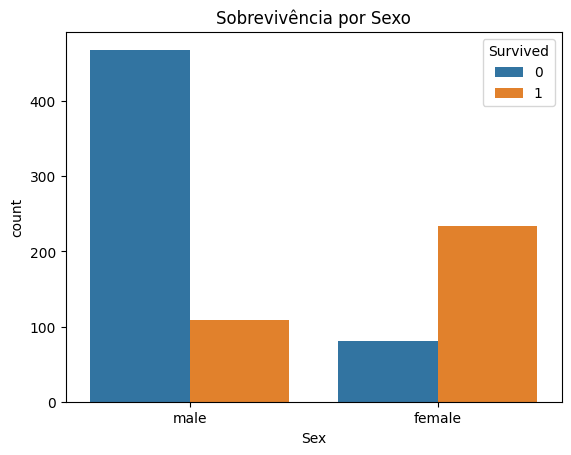

In [16]:
# Sobrevivência por Sexo
sns.countplot(x='Sex', hue='Survived', data=df)
plt.title('Sobrevivência por Sexo')
plt.show()

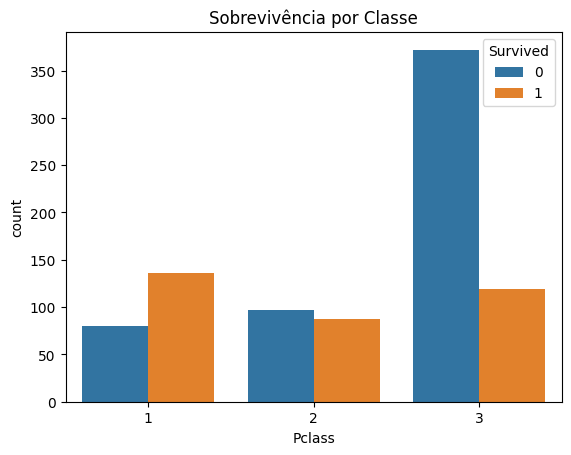

In [17]:

# Classe Social
sns.countplot(x='Pclass', hue='Survived', data=df)
plt.title('Sobrevivência por Classe')
plt.show()

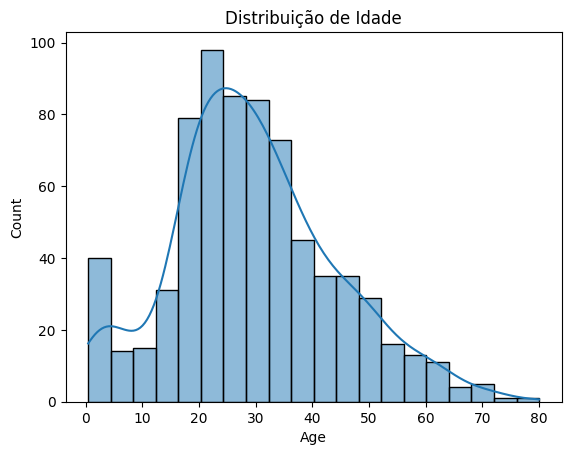

In [18]:
# Distribuição de Idade
sns.histplot(df['Age'], kde=True)
plt.title('Distribuição de Idade')
plt.show()

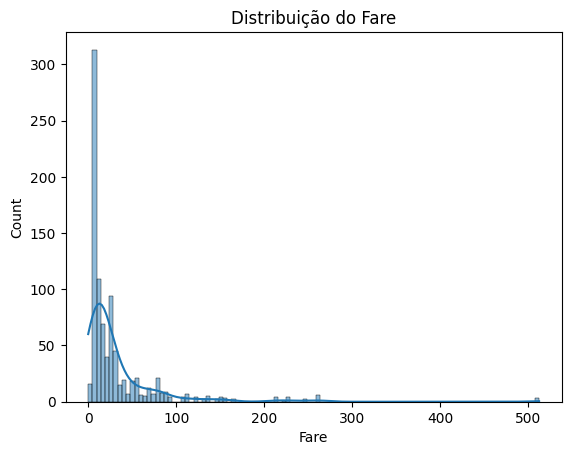

In [19]:

# Fare (Preço da passagem)
sns.histplot(df['Fare'], kde=True)
plt.title('Distribuição do Fare')
plt.show()


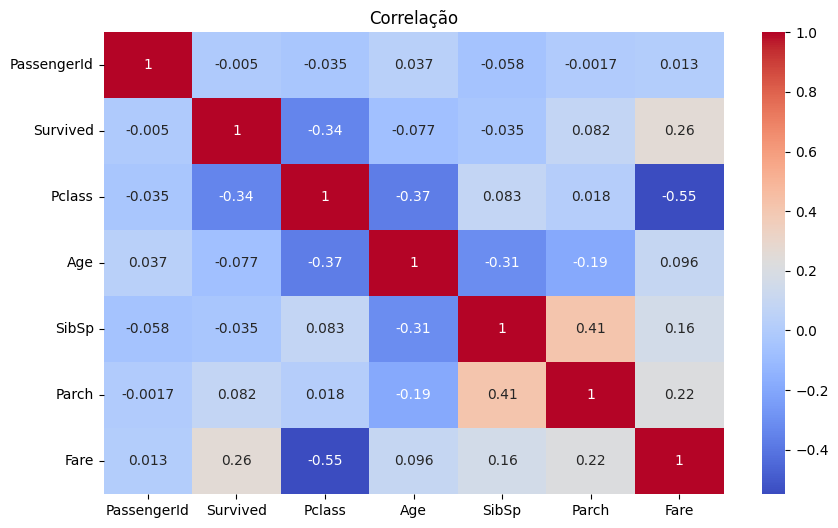

In [20]:
# Correlação entre variáveis
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.title('Correlação')
plt.show()

# Quanto mais próximo de 1, maior a correlação (mais forte).

## Tratamento de Dados

In [21]:
# Preenchimento

df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)

/tmp/ipykernel_16500/1864302538.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
/tmp/ipykernel_16500/1864302538.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', 

In [22]:
# Remoção de colunas

df.drop(['Cabin', 'Name', 'Ticket'], axis=1, inplace=True)



In [23]:
# Feature Engineering
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1


In [24]:
# Encoding

df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)


In [25]:
# Preparação dos Dados
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [26]:
# Normalização

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [27]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

In [28]:
log_model = LogisticRegression(random_state=42, solver='liblinear', max_iter=1000)
log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
print('Logistic Regression:', accuracy_score(y_test, log_pred))
print('Random Forest:', accuracy_score(y_test, rf_pred))

Logistic Regression: 0.8044692737430168
Random Forest: 0.8212290502793296


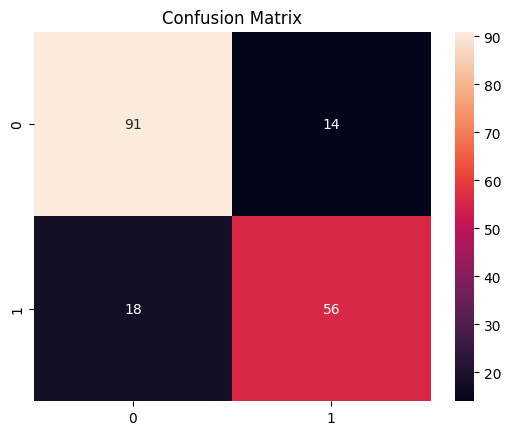

In [29]:
# Matriz de confusão

cm = confusion_matrix(y_test, rf_pred)
sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.show()


In [30]:
#  Relatório

print(classification_report(y_test, rf_pred))


              precision    recall  f1-score   support

           0       0.83      0.87      0.85       105
           1       0.80      0.76      0.78        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



In [31]:
# Validação Cruzada
scores = cross_val_score(rf_model, X, y, cv=5)
print('Cross-validation:', scores.mean())



Cross-validation: 0.8070805348063523


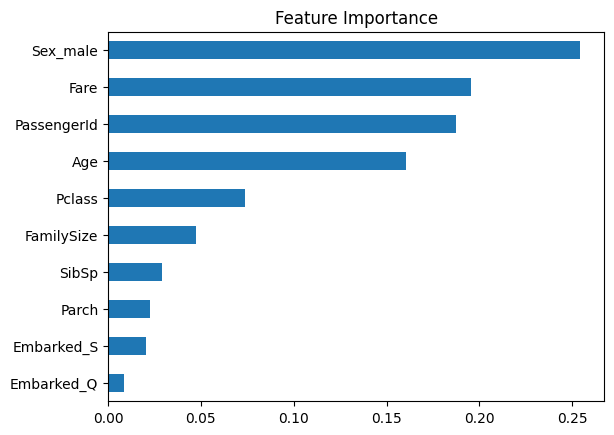

In [32]:

# Importância das Variáveis

rf_model.fit(X_train, y_train)
importances = pd.Series(rf_model.feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh')
plt.title('Feature Importance')
plt.show()


In [33]:
import pandas as pd
from sklearn.ensemble import RandomForestClassifier

# Usa o DataFrame 'df' que foi carregado e pré-processado.
# 'Survived' é a variável alvo para o treinamento.
y_submission = df["Survived"]

# Define as features para este modelo, ajustando para o estado atual de 'df'
# (onde 'Sex' foi transformado em 'Sex_male').
features_for_model = ["Pclass", "Sex_male", "SibSp", "Parch"]

# Prepara X para treinamento usando as features selecionadas do 'df'.
X_submission = df[features_for_model]

# Obtém o 'PassengerId' para o arquivo de submissão.
# Como não há um conjunto de dados de teste separado carregado,
# vamos usar os 'PassengerId' do próprio 'df' para demonstração da geração do arquivo de submissão.
passenger_ids = df["PassengerId"]

model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=1)
model.fit(X_submission, y_submission)

# Faz as previsões no mesmo conjunto de dados (X_submission) para demonstrar a criação do arquivo.
predictions = model.predict(X_submission)

# Cria o DataFrame de saída com 'PassengerId' e as previsões 'Survived'.
output = pd.DataFrame({'PassengerId': passenger_ids, 'Survived': predictions})
output.to_csv('submission.csv', index=False)
print("Seu arquivo para submeter esta disponivel !")

Seu arquivo para submeter esta disponivel !
